In [1]:
import sys
print(sys.executable)
print(sys.version)


c:\Users\SACHIN\AppData\Local\Python\pythoncore-3.14-64\python.exe
3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]


In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scipy yfinance openpyxl



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [4]:
stocks = [
    "APOLLOHOSP.NS",
    "DRREDDY.NS",
    "NTPC.NS",
    "POWERGRID.NS",
    "ABB.NS",
    "THERMAX.NS",
    "NESTLEIND.NS",
    "HINDUNILVR.NS",
    "EICHERMOT.NS",
    "BAJAJ-AUTO.NS"
]

In [5]:
data = yf.download(stocks, start="2021-01-01", end="2024-01-01")["Close"]

data = data.dropna(axis=1, how="all")
data = data.dropna()

print(data.shape)

[*********************100%***********************]  10 of 10 completed

(741, 10)


In [6]:
returns = data.pct_change().dropna()

In [7]:
annual_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

In [8]:
num_portfolios = 10000
risk_free = 0.03

results = np.zeros((3, num_portfolios))
weights_record = []

n = len(stocks)

for i in range(num_portfolios):
    weights = np.random.random(n)
    weights /= np.sum(weights)

    port_return = np.sum(weights * annual_returns)

    port_vol = np.sqrt(weights.T @ cov_matrix.values @ weights)

    sharpe = (port_return - risk_free) / port_vol

    results[0, i] = port_return
    results[1, i] = port_vol
    results[2, i] = sharpe

    weights_record.append(weights)

In [9]:
best_idx = np.argmax(results[2])

best_return = results[0, best_idx]
best_vol = results[1, best_idx]
best_sharpe = results[2, best_idx]
best_weights = weights_record[best_idx]

In [10]:
def neg_sharpe(weights, returns, cov, rf=0.03):
    port_return = np.sum(weights * returns)
    port_vol = np.sqrt(weights.T @ cov @ weights)
    return -(port_return - rf) / port_vol


constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(n))

init = np.array([1/n]*n)

optimal = minimize(
    neg_sharpe,
    init,
    args=(annual_returns.values, cov_matrix.values),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

opt_weights = optimal.x

In [11]:
opt_return = np.sum(opt_weights * annual_returns)
opt_vol = np.sqrt(opt_weights.T @ cov_matrix.values @ opt_weights)
opt_sharpe = (opt_return - risk_free) / opt_vol

In [12]:
equal_weights = np.array([1/n]*n)

eq_return = np.sum(equal_weights * annual_returns)
eq_vol = np.sqrt(equal_weights.T @ cov_matrix.values @ equal_weights)
eq_sharpe = (eq_return - risk_free) / eq_vol







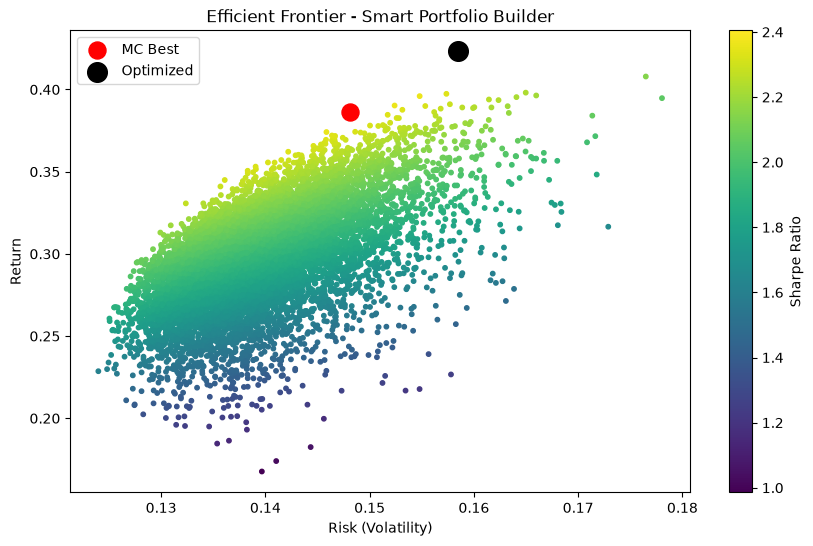

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(results[1], results[0], c=results[2], cmap="viridis", s=10)
plt.colorbar(label="Sharpe Ratio")

plt.scatter(best_vol, best_return, color="red", s=150, label="MC Best")
plt.scatter(opt_vol, opt_return, color="black", s=200, label="Optimized")

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Efficient Frontier - Smart Portfolio Builder")
plt.legend()
plt.show()

[*********************100%***********************]  1 of 1 completed


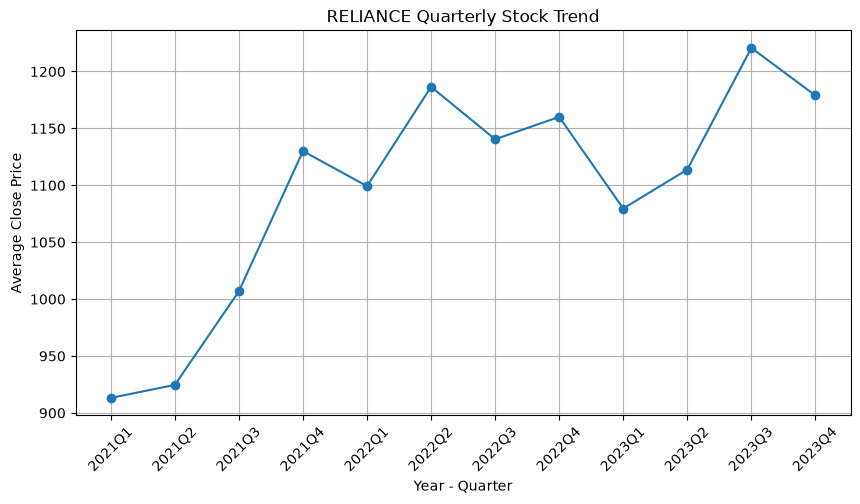

In [14]:
import yfinance as yf
import matplotlib.pyplot as plt

stock = "RELIANCE.NS"

data = yf.download(stock, start="2021-01-01", end="2024-01-01")

# Create Quarter label
data["YearQuarter"] = data.index.to_period("Q")

# Group by Year-Quarter and take mean Close price
quarterly_price = data.groupby("YearQuarter")["Close"].mean()

plt.figure(figsize=(10,5))
plt.plot(quarterly_price.index.astype(str), quarterly_price.values, marker="o")

plt.title("RELIANCE Quarterly Stock Trend")
plt.xlabel("Year - Quarter")
plt.ylabel("Average Close Price")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

[*********************100%***********************]  1 of 1 completed


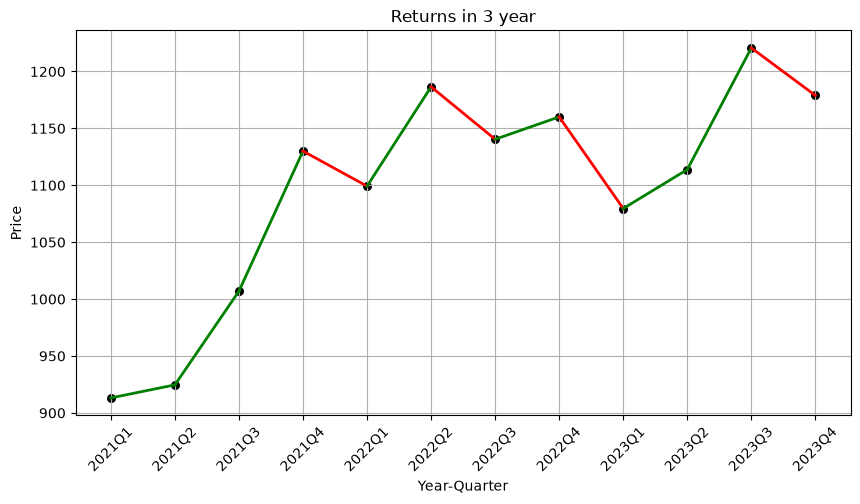

In [15]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

stock = "RELIANCE.NS"

data = yf.download(stock, start="2021-01-01", end="2024-01-01")

# Quarterly data
data["YearQuarter"] = data.index.to_period("Q")
q = data.groupby("YearQuarter")["Close"].mean()

x = np.arange(len(q))
y = q.values

plt.figure(figsize=(10,5))

# draw colored line segment by segment
for i in range(1, len(y)):
    if y[i] >= y[i-1]:
        color = "green"   # up move
    else:
        color = "red"     # down move

    plt.plot(x[i-1:i+1], y[i-1:i+1], color=color, linewidth=2)

# points
plt.scatter(x, y, color="black", s=30)

plt.xticks(x, q.index.astype(str), rotation=45)
plt.title("Returns in 3 year")
plt.xlabel("Year-Quarter")
plt.ylabel("Price")
plt.grid(True)

plt.show()

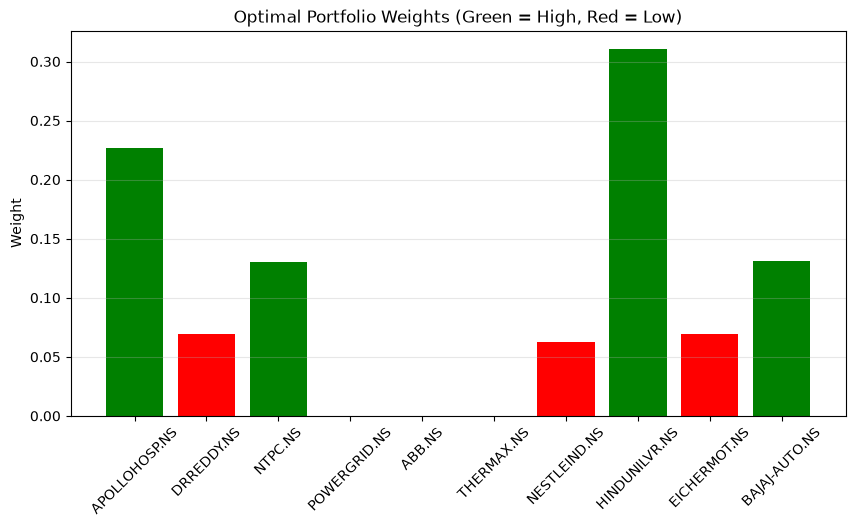

In [16]:
import matplotlib.pyplot as plt
import numpy as np

avg_weight = np.mean(opt_weights)

colors = ["green" if w >= avg_weight else "red" for w in opt_weights]

plt.figure(figsize=(10,5))
plt.bar(stocks, opt_weights, color=colors)

plt.xticks(rotation=45)
plt.title("Optimal Portfolio Weights (Green = High, Red = Low)")
plt.ylabel("Weight")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [17]:
print("EQUAL WEIGHT vs OPTIMAL PORTFOLIO\n")

print("Equal Return:", eq_return)
print("Optimal Return:", opt_return)

print("\nEqual Volatility:", eq_vol)
print("Optimal Volatility:", opt_vol)

print("\nEqual Sharpe:", eq_sharpe)
print("Optimal Sharpe:", opt_sharpe)

EQUAL WEIGHT vs OPTIMAL PORTFOLIO

Equal Return: 0.2979031024841081
Optimal Return: 0.4231162702096807

Equal Volatility: 0.13267285615747113
Optimal Volatility: 0.15844504743395746

Equal Sharpe: 2.0192759110132554
Optimal Sharpe: 2.481089037342982


In [18]:
import yfinance as yf
import pandas as pd

stocks = [
    "APOLLOHOSP.NS",
    "DRREDDY.NS",
    "NTPC.NS",
    "POWERGRID.NS",
    "ABB.NS",
    "THERMAX.NS",
    "NESTLEIND.NS",
    "HINDUNILVR.NS",
    "EICHERMOT.NS",
    "BAJAJ-AUTO.NS"
]

data = yf.download(stocks, start="2021-01-01", end="2024-01-01")

[*********************100%***********************]  10 of 10 completed


In [19]:
print(data.columns)

MultiIndex([( 'Close',        'ABB.NS'),
            ( 'Close', 'APOLLOHOSP.NS'),
            ( 'Close', 'BAJAJ-AUTO.NS'),
            ( 'Close',    'DRREDDY.NS'),
            ( 'Close',  'EICHERMOT.NS'),
            ( 'Close', 'HINDUNILVR.NS'),
            ( 'Close',  'NESTLEIND.NS'),
            ( 'Close',       'NTPC.NS'),
            ( 'Close',  'POWERGRID.NS'),
            ( 'Close',    'THERMAX.NS'),
            (  'High',        'ABB.NS'),
            (  'High', 'APOLLOHOSP.NS'),
            (  'High', 'BAJAJ-AUTO.NS'),
            (  'High',    'DRREDDY.NS'),
            (  'High',  'EICHERMOT.NS'),
            (  'High', 'HINDUNILVR.NS'),
            (  'High',  'NESTLEIND.NS'),
            (  'High',       'NTPC.NS'),
            (  'High',  'POWERGRID.NS'),
            (  'High',    'THERMAX.NS'),
            (   'Low',        'ABB.NS'),
            (   'Low', 'APOLLOHOSP.NS'),
            (   'Low', 'BAJAJ-AUTO.NS'),
            (   'Low',    'DRREDDY.NS'),
            (   

In [20]:
high = data["High"]
print(high.head())
df = pd.DataFrame(high.head())
df


Ticker           ABB.NS  APOLLOHOSP.NS  BAJAJ-AUTO.NS   DRREDDY.NS  \
Date                                                                 
2021-01-01  1192.630524    2398.637723    3013.033228  1012.032048   
2021-01-04  1242.223123    2397.650618    3042.353196  1022.335587   
2021-01-05  1256.667629    2483.379555    3022.519185  1027.853311   
2021-01-06  1267.260204    2506.082482    3041.491067  1023.616427   
2021-01-07  1268.126772    2530.907873    3024.546093  1025.542241   

Ticker      EICHERMOT.NS  HINDUNILVR.NS  NESTLEIND.NS    NTPC.NS  \
Date                                                               
2021-01-01   2410.695684    2188.471483    871.304243  81.005018   
2021-01-04   2519.200401    2212.140067    876.479368  80.843334   
2021-01-05   2533.353383    2236.674024    876.008976  79.549833   
2021-01-06   2521.087609    2230.347367    875.068004  80.034909   
2021-01-07   2562.272061    2214.598351    875.773647  79.630680   

Ticker      POWERGRID.NS  THERMA

Ticker,ABB.NS,APOLLOHOSP.NS,BAJAJ-AUTO.NS,DRREDDY.NS,EICHERMOT.NS,HINDUNILVR.NS,NESTLEIND.NS,NTPC.NS,POWERGRID.NS,THERMAX.NS
Date,,,,,,,,,,
2021-01-01,1192.630524,2398.637723,3013.033228,1012.032048,2410.695684,2188.471483,871.304243,81.005018,81.064051,898.390284
2021-01-04,1242.223123,2397.650618,3042.353196,1022.335587,2519.200401,2212.140067,876.479368,80.843334,81.277489,903.272744
2021-01-05,1256.667629,2483.379555,3022.519185,1027.853311,2533.353383,2236.674024,876.008976,79.549833,80.893299,937.548300
2021-01-06,1267.260204,2506.082482,3041.491067,1023.616427,2521.087609,2230.347367,875.068004,80.034909,84.351009,943.749178
2021-01-07,1268.126772,2530.907873,3024.546093,1025.542241,2562.272061,2214.598351,875.773647,79.630680,86.143894,957.957420


In [21]:
low = data["Low"]
print(low.head())
df = pd.DataFrame(low.head())
df

Ticker           ABB.NS  APOLLOHOSP.NS  BAJAJ-AUTO.NS   DRREDDY.NS  \
Date                                                                 
2021-01-01  1167.111987    2364.089443    2971.640671  1001.468510   
2021-01-04  1189.260121    2367.297487    2988.025460  1009.432028   
2021-01-05  1179.630533    2355.007983    2996.648836  1006.658763   
2021-01-06  1243.186112    2448.979025    2962.931346  1006.475861   
2021-01-07  1243.426733    2467.733886    2956.334514  1011.675731   

Ticker      EICHERMOT.NS  HINDUNILVR.NS  NESTLEIND.NS    NTPC.NS  \
Date                                                               
2021-01-01   2373.709714    2168.443874    861.238600  79.873217   
2021-01-04   2434.283533    2185.466894    862.353595  79.630684   
2021-01-05   2468.250447    2189.381606    859.921392  78.418025   
2021-01-06   2462.589318    2186.286716    867.070071  78.620151   
2021-01-07   2491.602448    2152.967980    849.196991  78.296764   

Ticker      POWERGRID.NS  THERMA

Ticker,ABB.NS,APOLLOHOSP.NS,BAJAJ-AUTO.NS,DRREDDY.NS,EICHERMOT.NS,HINDUNILVR.NS,NESTLEIND.NS,NTPC.NS,POWERGRID.NS,THERMAX.NS
Date,,,,,,,,,,
2021-01-01,1167.111987,2364.089443,2971.640671,1001.468510,2373.709714,2168.443874,861.238600,79.873217,80.466418,880.813083
2021-01-04,1189.260121,2367.297487,2988.025460,1009.432028,2434.283533,2185.466894,862.353595,79.630684,80.252979,885.744358
2021-01-05,1179.630533,2355.007983,2996.648836,1006.658763,2468.250447,2189.381606,859.921392,78.418025,79.484606,890.626952
2021-01-06,1243.186112,2448.979025,2962.931346,1006.475861,2462.589318,2186.286716,867.070071,78.620151,79.826107,920.849980
2021-01-07,1243.426733,2467.733886,2956.334514,1011.675731,2491.602448,2152.967980,849.196991,78.296764,83.454568,936.620676


In [22]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print(data)
# df = pd.DataFrame(data)
# df

Price             Close                                                        \
Ticker           ABB.NS APOLLOHOSP.NS BAJAJ-AUTO.NS   DRREDDY.NS EICHERMOT.NS   
Date                                                                            
2021-01-01  1187.045288   2383.683350   3002.038330  1009.432129  2399.090332   
2021-01-04  1216.126831   2378.155518   3037.567139  1015.382996  2505.708008   
2021-01-05  1245.689819   2477.062012   3011.869141  1018.204529  2523.823730   
2021-01-06  1249.589844   2469.855957   2986.042236  1018.474304  2495.942871   
2021-01-07  1254.404541   2476.173584   2964.699219  1015.123169  2500.141357   
2021-01-08  1266.296997   2520.543457   3043.344971  1028.094116  2604.919434   
2021-01-11  1248.867432   2517.631592   3119.403809  1043.221924  2620.298828   
2021-01-12  1222.289795   2484.761475   3125.353760  1031.098389  2718.896729   
2021-01-13  1233.074951   2447.202881   3105.218018  1018.801575  2706.630859   
2021-01-14  1227.200562   24

In [23]:
print(data["High"]["APOLLOHOSP.NS"].head())
print(data["Low"]["APOLLOHOSP.NS"].head())




Date
2021-01-01    2398.637723
2021-01-04    2397.650618
2021-01-05    2483.379555
2021-01-06    2506.082482
2021-01-07    2530.907873
Name: APOLLOHOSP.NS, dtype: float64
Date
2021-01-01    2364.089443
2021-01-04    2367.297487
2021-01-05    2355.007983
2021-01-06    2448.979025
2021-01-07    2467.733886
Name: APOLLOHOSP.NS, dtype: float64


In [24]:
high_low = pd.concat([data["High"], data["Low"]], axis=1, keys=["High", "Low"])

print(high_low.head())
df = pd.DataFrame(high_low.head())



                   High                                                        \
Ticker           ABB.NS APOLLOHOSP.NS BAJAJ-AUTO.NS   DRREDDY.NS EICHERMOT.NS   
Date                                                                            
2021-01-01  1192.630524   2398.637723   3013.033228  1012.032048  2410.695684   
2021-01-04  1242.223123   2397.650618   3042.353196  1022.335587  2519.200401   
2021-01-05  1256.667629   2483.379555   3022.519185  1027.853311  2533.353383   
2021-01-06  1267.260204   2506.082482   3041.491067  1023.616427  2521.087609   
2021-01-07  1268.126772   2530.907873   3024.546093  1025.542241  2562.272061   

                                                                           \
Ticker     HINDUNILVR.NS NESTLEIND.NS    NTPC.NS POWERGRID.NS  THERMAX.NS   
Date                                                                        
2021-01-01   2188.471483   871.304243  81.005018    81.064051  898.390284   
2021-01-04   2212.140067   876.479368  80.8

In [25]:
df

High                                                        \
Ticker           ABB.NS APOLLOHOSP.NS BAJAJ-AUTO.NS   DRREDDY.NS EICHERMOT.NS   
Date                                                                            
2021-01-01  1192.630524   2398.637723   3013.033228  1012.032048  2410.695684   
2021-01-04  1242.223123   2397.650618   3042.353196  1022.335587  2519.200401   
2021-01-05  1256.667629   2483.379555   3022.519185  1027.853311  2533.353383   
2021-01-06  1267.260204   2506.082482   3041.491067  1023.616427  2521.087609   
2021-01-07  1268.126772   2530.907873   3024.546093  1025.542241  2562.272061   

                                                                           \
Ticker     HINDUNILVR.NS NESTLEIND.NS    NTPC.NS POWERGRID.NS  THERMAX.NS   
Date                                                                        
2021-01-01   2188.471483   871.304243  81.005018    81.064051  898.390284   
2021-01-04   2212.140067   876.479368  80.843334    81.277489  903.272744   
2021-01-05   2236.674024   876.008976  79.549833    80.893299  937.548300   
2021-01-06   2230.347367   875.068004  80.034909    84.351009  943.749178   
2021-01-07   2214.598351   875.773647  79.630680    86.143894  957.957420   

                    Low                                                        \
Ticker           ABB.NS APOLLOHOSP.NS BAJAJ-AUTO.NS   DRREDDY.NS EICHERMOT.NS   
Date                                                                            
2021-01-01  1167.111987   2364.089443   2971.640671  1001.468510  2373.709714   
2021-01-04  1189.260121   2367.297487   2988.025460  1009.432028  2434.283533   
2021-01-05  1179.630533   2355.007983   2996.648836  1006.658763  2468.250447   
2021-01-06  1243.186112   2448.979025   2962.931346  1006.475861  2462.589318   
2021-01-07  1243.426733   2467.733886   2956.334514  1011.675731  2491.602448   

                                                                           
Ticker     HINDUNILVR.NS NESTLEIND.NS    NTPC.NS POWERGRID.NS  THERMAX.NS  
Date                                                                       
2021-01-01   2168.443874   861.238600  79.873217    80.466418  880.813083  
2021-01-04   2185.466894   862.353595  79.630684    80.252979  885.744358  
2021-01-05   2189.381606   859.921392  78.418025    79.484606  890.626952  
2021-01-06   2186.286716   867.070071  78.620151    79.826107  920.849980  
2021-01-07   2152.967980   849.196991  78.296764    83.454568  936.620676

In [26]:
df1 = pd.DataFrame(data["High"]["APOLLOHOSP.NS"].head())
df1


,APOLLOHOSP.NS
Date,
2021-01-01,2398.637723
2021-01-04,2397.650618
2021-01-05,2483.379555
2021-01-06,2506.082482
2021-01-07,2530.907873


In [27]:
df = pd.DataFrame(data["Low"]["APOLLOHOSP.NS"].head())
df

,APOLLOHOSP.NS
Date,
2021-01-01,2364.089443
2021-01-04,2367.297487
2021-01-05,2355.007983
2021-01-06,2448.979025
2021-01-07,2467.733886


In [28]:
import sys
!{sys.executable} -m pip install jinja2


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import sys
!{sys.executable} -m ensurepip --upgrade
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install jinja2

Looking in links: c:\Users\SACHIN\AppData\Local\Temp\tmpb7hedlps


   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------- ---------------------- 0.8/1.8 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 6.6 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.1.2
    Uninstalling pip-26.1.2:
      Successfully uninstalled pip-26.1.2


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [30]:
df.style.background_gradient(cmap="RdYlGn")

,APOLLOHOSP.NS
Date,
2021-01-01 00:00:00,2364.089443
2021-01-04 00:00:00,2367.297487
2021-01-05 00:00:00,2355.007983
2021-01-06 00:00:00,2448.979025
2021-01-07 00:00:00,2467.733886


In [31]:
data["High"]["APOLLOHOSP.NS"]
data["Low"]["APOLLOHOSP.NS"]

Date
2021-01-01    2364.089443
2021-01-04    2367.297487
2021-01-05    2355.007983
2021-01-06    2448.979025
2021-01-07    2467.733886
2021-01-08    2483.231272
2021-01-11    2491.917756
2021-01-12    2475.828229
2021-01-13    2406.287891
2021-01-14    2443.057120
2021-01-15    2477.704117
2021-01-18    2514.177278
2021-01-19    2546.701330
2021-01-20    2609.135433
2021-01-21    2541.174074
2021-01-22    2533.968313
2021-01-25    2577.153879
2021-01-27    2553.858193
2021-01-28    2547.244476
2021-01-29    2518.076137
2021-02-01    2495.471172
2021-02-02    2643.436832
2021-02-03    2669.101520
2021-02-04    2651.333798
2021-02-05    2652.962027
2021-02-08    2689.830697
2021-02-09    2702.761148
2021-02-10    2710.213765
2021-02-11    2694.765845
2021-02-12    2690.916505
2021-02-15    2724.822483
2021-02-16    3007.674233
2021-02-17    3135.996853
2021-02-18    3054.067876
2021-02-19    2858.623557
2021-02-22    2829.898912
2021-02-23    2899.587697
2021-02-24    2961.330732
2021-02

In [32]:
df.head().style.set_properties(**{
    "text-align": "center",
    "font-weight": "bold"
}).apply(
    lambda col: ["background-color: lightgreen" if col.name == "High"
                 else "background-color: lightcoral"
                 for _ in col]
)

,APOLLOHOSP.NS
Date,
2021-01-01 00:00:00,2364.089443
2021-01-04 00:00:00,2367.297487
2021-01-05 00:00:00,2355.007983
2021-01-06 00:00:00,2448.979025
2021-01-07 00:00:00,2467.733886


In [33]:
high_df = data["High"]
low_df = data["Low"]

df = pd.concat([high_df, low_df], axis=1, keys=["High", "Low"])


In [34]:
def highlight_columns(col):
    if col.name[0] == "High":
        return ["background-color: green; color: white"] * len(col)
    elif col.name[0] == "Low":
        return ["background-color: red; color: white"] * len(col)
    return [""] * len(col)

df.head().style.apply(highlight_columns, axis=0)

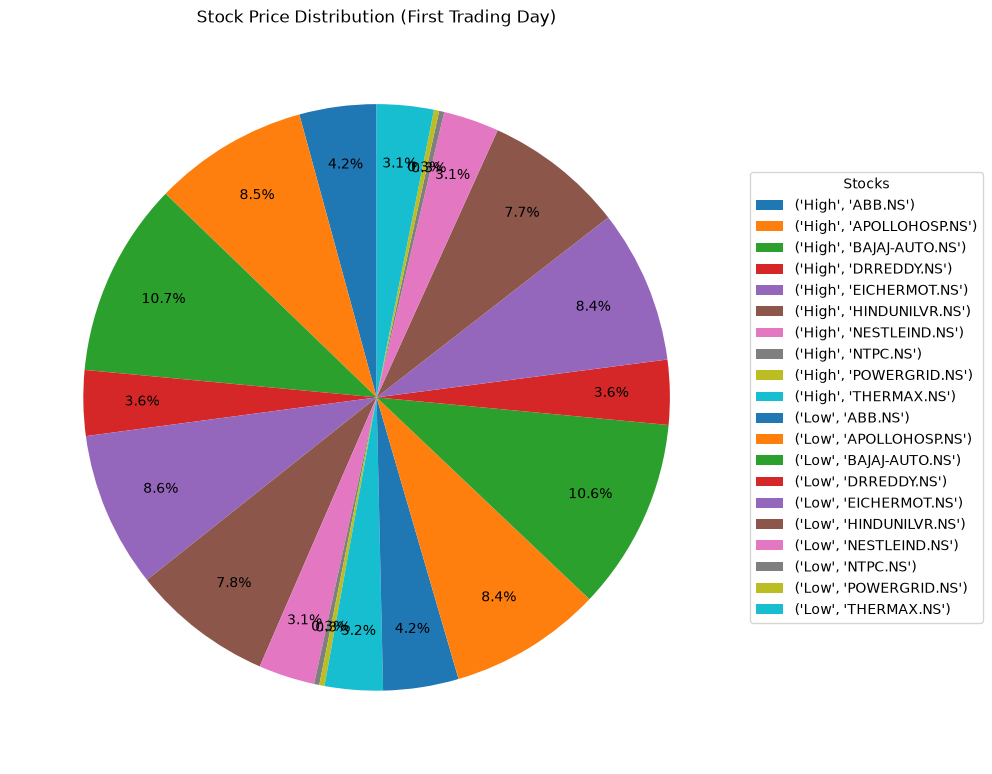

In [35]:
import matplotlib.pyplot as plt

# Select one date (or one month's average)
values = df.iloc[0]      # First row
labels = df.columns

plt.figure(figsize=(10,10))

wedges, texts, autotexts = plt.pie(
    values,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8
)

plt.legend(
    wedges,
    labels,
    title="Stocks",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Stock Price Distribution (First Trading Day)")
plt.tight_layout()
plt.show()

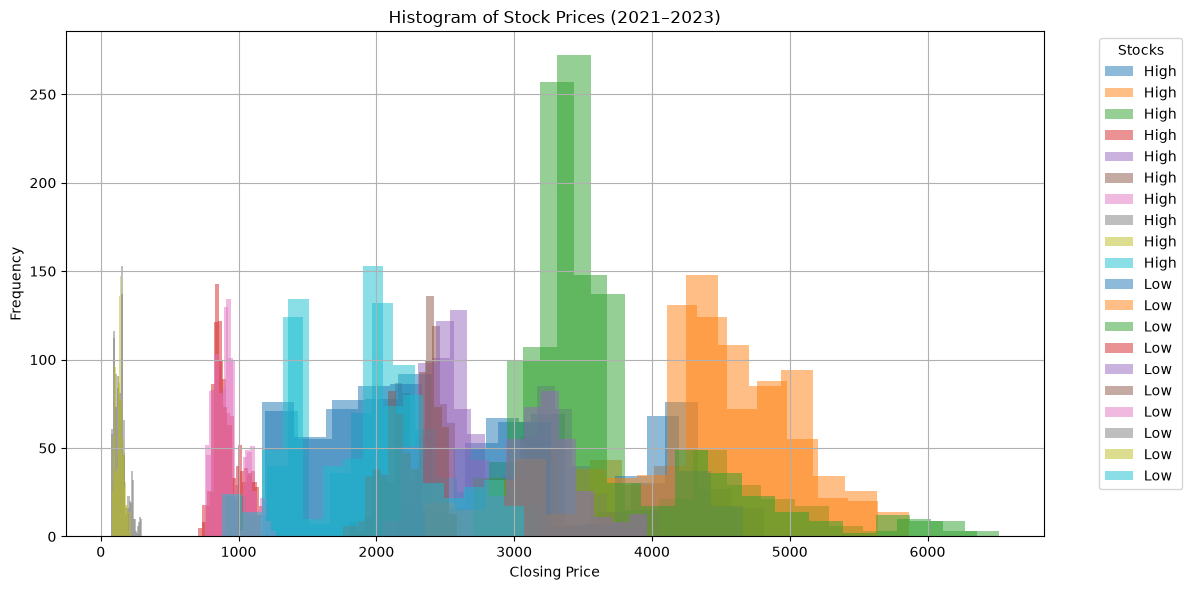

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for stock in df.columns:
    plt.hist(df[stock], bins=15, alpha=0.5, label=stock)

plt.title("Histogram of Stock Prices (2021–2023)")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.legend(title="Stocks", bbox_to_anchor=(1.05,1), loc="upper left")

plt.grid(True)
plt.tight_layout()
plt.show()

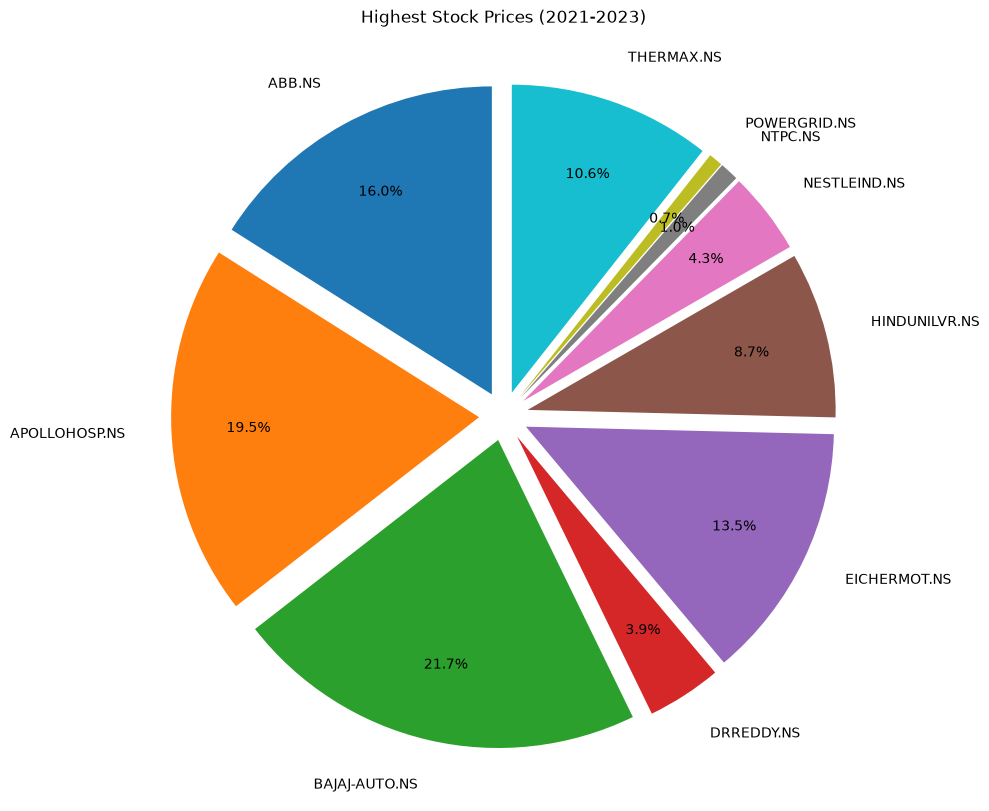

In [37]:
# import matplotlib.pyplot as plt

# # Extract High prices only
# high_values = df['High'].max()

# plt.figure(figsize=(9,9))

# plt.pie(
#     high_values,
#     labels=high_values.index,
#     autopct='%1.1f%%',
#     startangle=90,
#     textprops={'fontsize':10}
# )

# plt.title("Highest Stock Prices (2021-2023)")
# plt.show()
import matplotlib.pyplot as plt

high_values = df['High'].max()

# Add space between slices
explode = [0.08] * len(high_values)

plt.figure(figsize=(10,10))

plt.pie(
    high_values,
    labels=high_values.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,       # distance between slices
    labeldistance=1.15,    # distance of labels from pie
    pctdistance=0.75,      # distance of percentage text
    textprops={'fontsize':10}
)

plt.title("Highest Stock Prices (2021-2023)")
plt.show()

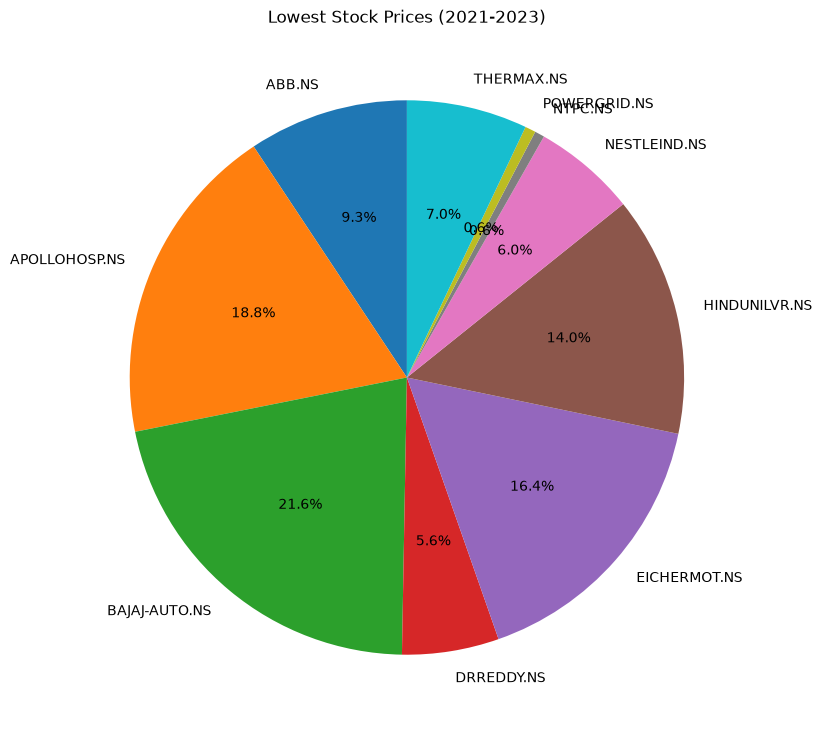

In [38]:
# Extract Low prices only
low_values = df['Low'].min()

plt.figure(figsize=(9,9))

plt.pie(
    low_values,
    labels=low_values.index,
    
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize':10}
)

plt.title("Lowest Stock Prices (2021-2023)")
plt.show()

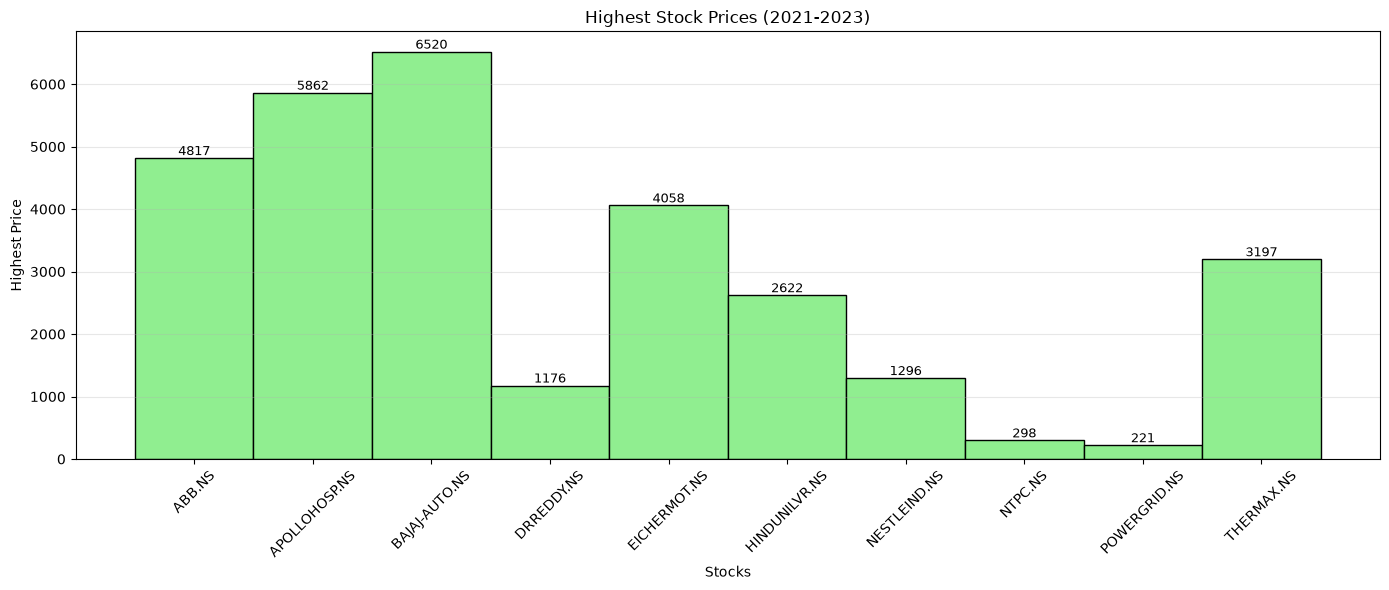

In [39]:
import matplotlib.pyplot as plt

high_values = df['High'].max()

plt.figure(figsize=(14,6))

bars = plt.bar(
    high_values.index,
    high_values.values,
    color='lightgreen',
    edgecolor='black',
    width=1              # reduce bar width (more gap)
)

plt.title("Highest Stock Prices (2021-2023)")
plt.xlabel("Stocks")
plt.ylabel("Highest Price")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

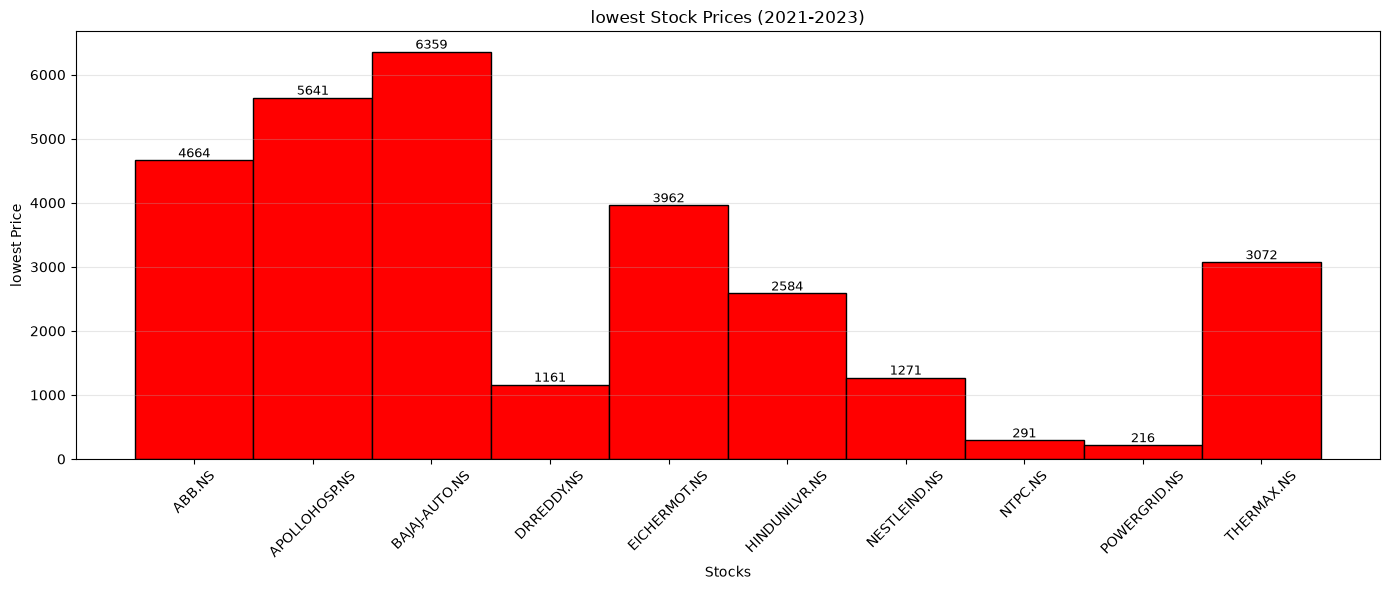

In [44]:
import matplotlib.pyplot as plt

low_values= df['Low'].max()

plt.figure(figsize=(14,6))

bars = plt.bar(
    low_values.index,
    low_values.values,
    color='red',
    edgecolor='black',
    width=1              # reduce bar width (more gap)
)

plt.title("lowest Stock Prices (2021-2023)")
plt.xlabel("Stocks")
plt.ylabel("lowest Price")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()